In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
nrounds = [1, 2, 4, 6, 8]
ers = [0.0001, 0.000316, 0.001, 0.00316, 0.01]
def toDecimal(binary):
    return int(binary, 2)
def toBinary(decimal):
    return format(decimal, '08b')
def parity(x):
    p = 0
    while x:
        p ^= 1
        x &= x - 1    # removes the lowest set bit
    return p          # 0 = even, 1 = odd
def measure_logical(log, readout):
    count = 0
    for i in range(len(readout)):
        if readout[i] == '1' and log[i] == '1':
            count += 1
    return count % 2
def weight(bitstring):
    return sum([int(bit) for bit in bitstring])


In [219]:
defaultcolors = ['#FF7F7F', '#7F7FFF']
def plot_data(data, data2 = None, title = None, color1 = defaultcolors[0], color2 = defaultcolors[1], pad = 0.1, info = None):
    """
    data: 2darray for default plot
    data2: 2darray for secondary plot, should be shorter than data
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_proj_type("ortho")
    x = np.arange(len(nrounds))
    y = np.arange(len(ers))
    xv, yv = np.meshgrid(x, y, indexing='ij')
    xv, yv = xv.flatten(), yv.flatten()
    z1 = data.flatten()
    if data2 is not None:
        z2 = data2.flatten()
        order = np.argsort(xv + yv)[::1]
        for i in order:
            ax.bar3d(xv[i] + 0.5, yv[i], 0, 0.5, 1, z1[i], color = color1, edgecolor = 'black', linewidth = 0.5, alpha = 1)
            ax.bar3d(xv[i], yv[i], 0, 0.5, 1, z2[i], color = color2, edgecolor = 'black', linewidth = 0.5, alpha = 1)
       
    else:
        ax.bar3d(xv + pad, yv + pad, 0, 1 - 2*pad, 1 - 2*pad, z1, color = color1, edgecolor = 'black', linewidth = 0.5, alpha = 1)
    for i in range(len(nrounds)):
        for j in range(len(ers)):
            ax.text(x[i] + 0.5, y[j] + 0.5, z1[i*len(ers) + j], f'{z1[i*len(ers) + j]:.4f}'[1:], ha='center', va='center', fontsize=10, zorder=10000)
       

    ax.set_xticks(np.arange(len(nrounds)))
    ax.set_xticklabels([])
    for idx, label in enumerate(nrounds):
        ax.text(idx + 0.5, -0.2, 0, str(label), ha='center', va='top', fontsize=10)
    ax.set_xlabel('Number of rounds')
    ax.set_xlim(0, len(nrounds))

    ax.set_yticks(np.arange(len(ers)))
    ax.set_yticklabels([])
    for idy, label in enumerate(ers):
        ax.text(-0.2, idy + 0.5, 0, str(label), ha='right', va='top', fontsize=10)
    ax.set_ylabel('p_error')
    ax.set_ylim(0, len(ers))

    ax.set_zlim(0, 1)
    plt.title(title)
    ax.view_init(elev=15, azim=240)
    if info is not None:
        at = AnchoredText(f'Notes:\n{info}', frameon=True, loc='upper right')
        ax.add_artist(at)
    plt.savefig(f'Plots/{title}.png')
    plt.show()

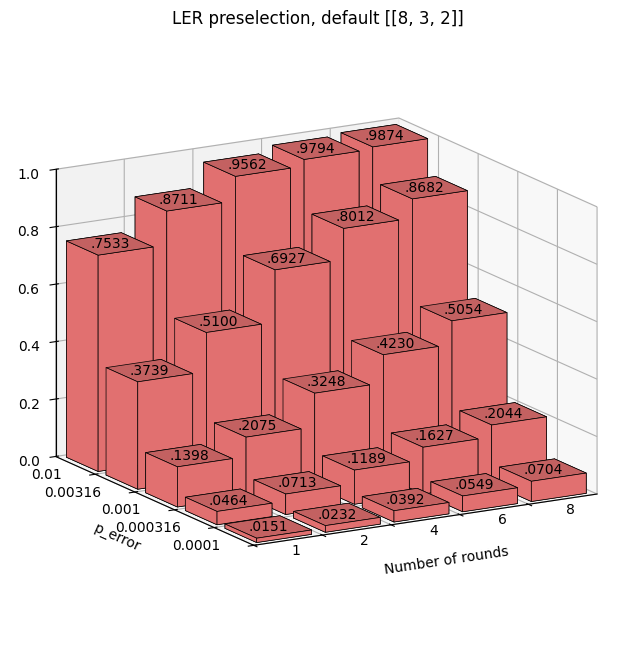

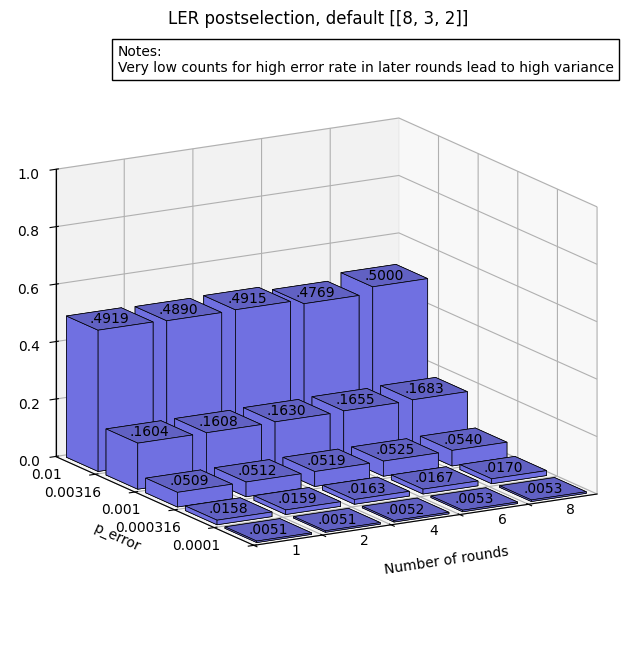

In [238]:
name = 'default'
data = np.fromfile(f'Data/output_{name}.bin', dtype=np.int32).reshape(5, 5, 514)
ncorrectall = data[:, :, 0] + data[:, :, 255]
ncorrectpost = data[:, :, 256] + data[:, :, 511]
lerpre = 1- (ncorrectall / np.sum(data[:, :, 0:256], axis = 2))
lerpost = 1- (ncorrectpost / np.sum(data[:, :, 256:512], axis = 2))
plot_data(lerpre, title = f'LER preselection, {name} [[8, 3, 2]]', color1 = defaultcolors[0])
info = 'Very low counts for high error rate in later rounds lead to high variance'
plot_data(lerpost, title = f'LER postselection, {name} [[8, 3, 2]]', color1 = defaultcolors[1], info = info)

In [239]:
# Create set of all logical operators
row, col = 0, 4 

logicalerrors = {}
for i in range(1, 256):
    if parity(i) == 0:
        logicalerrors[toBinary(i)] = 0
print(len(logicalerrors), logicalerrors.keys())
# Logical error rate for all logical qubits
for log in logicalerrors:
    for i in range(1, 256):
        if measure_logical(log, toBinary(i)) == 1:
            logicalerrors[log] += data[row, col, i]
            #logicalerrors[log] += data[row, col, i+256] / (data[row, col, 512] - data[row, col, 513])

127 dict_keys(['00000011', '00000101', '00000110', '00001001', '00001010', '00001100', '00001111', '00010001', '00010010', '00010100', '00010111', '00011000', '00011011', '00011101', '00011110', '00100001', '00100010', '00100100', '00100111', '00101000', '00101011', '00101101', '00101110', '00110000', '00110011', '00110101', '00110110', '00111001', '00111010', '00111100', '00111111', '01000001', '01000010', '01000100', '01000111', '01001000', '01001011', '01001101', '01001110', '01010000', '01010011', '01010101', '01010110', '01011001', '01011010', '01011100', '01011111', '01100000', '01100011', '01100101', '01100110', '01101001', '01101010', '01101100', '01101111', '01110001', '01110010', '01110100', '01110111', '01111000', '01111011', '01111101', '01111110', '10000001', '10000010', '10000100', '10000111', '10001000', '10001011', '10001101', '10001110', '10010000', '10010011', '10010101', '10010110', '10011001', '10011010', '10011100', '10011111', '10100000', '10100011', '10100101', '

In [240]:
# Sort logicalerrors by value
for log, val in sorted(logicalerrors.items(), key=lambda item: item[1]):
    print(f"{log}: {val}")

00110000: 258276
00000011: 258639
00011000: 260212
01100000: 261107
00000110: 261334
00001100: 263256
11000000: 263816
00000101: 267053
00010100: 267262
01010000: 267463
00101000: 271590
10100000: 271805
00001010: 272406
00010010: 275840
00100100: 277824
00001001: 277897
10010000: 278361
01001000: 280863
00010001: 281445
00100010: 286282
01000100: 286881
10001000: 291409
00100001: 291999
01000010: 295355
10000100: 296457
01000001: 300024
10000010: 304173
10000001: 308864
00110011: 383339
01100011: 383958
00011011: 384177
00110110: 384638
01111000: 384753
00111100: 385188
00011110: 385542
01100110: 385793
00001111: 385795
11110000: 385884
11011000: 386316
01101100: 386807
11000011: 386949
11000110: 387160
00110101: 387329
01010011: 387474
00010111: 387583
00011101: 387887
01100101: 388540
11001100: 388570
01110100: 388651
01010110: 388925
00111010: 389522
01011100: 389539
00101011: 389671
11000101: 389989
11010100: 389996
10100011: 390162
00101110: 390484
10111000: 390543
01010101: 3909

In [235]:
# Error rates for all individual physical qubits
physicalqubits = np.zeros(8)
readoutweights = np.zeros(9)
for i in range(0, 256):
    bitstring = toBinary(i)
    readoutweights[weight(bitstring)] += data[row, col, i + 256]
    if parity(i) == 0:
        continue
    for j in range(0, 8):
        if bitstring[j] == '1':
            physicalqubits[j] += data[row, col, i + 256]
print(physicalqubits, readoutweights)


[30603. 30493. 30516. 30295. 30507. 30377. 30446. 30681.] [1.93323e+05 3.00170e+04 2.71300e+03 2.28000e+02 2.50000e+01 1.87000e+02
 2.63000e+03 3.03260e+04 1.94245e+05]
